In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

BASE_DIR = Path("./animal_face_images")
TEST_DIR = Path("./test_images")

IMG_SIZE = 64

LABEL_MAP = {
    "강아지상": 0,
    "고양이상": 1,
    "여우상": 4
}

LABEL_NAME = {value: key for key, value in LABEL_MAP.items()}

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("설정 완료")
print(f"학습 데이터 경로: {BASE_DIR.resolve()}")
print(f"판별용 데이터 경로: {TEST_DIR.resolve()}")

def read_image_cv2(image_path):
    img_array = np.fromfile(str(image_path), np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

def preprocess_face(image_path):
    img = read_image_cv2(image_path)

    if img is None:
        return None

    img = cv2.resize(img, (300, 300), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=4,
        minSize=(50, 50)
    )

    if len(faces) > 0:
        x, y, w, h = faces[0]
        cropped_face = gray[y:y+h, x:x+w]
    else:
        cropped_face = gray

    resized_face = cv2.resize(
        cropped_face,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return resized_face.flatten()

flattened_data = []
labels = []

if not BASE_DIR.exists():
    raise FileNotFoundError("animal_face_images 폴더가 없습니다.")

for folder_name, label_value in LABEL_MAP.items():
    folder_path = BASE_DIR / folder_name

    if not folder_path.exists():
        print(f"{folder_name} 폴더 없음")
        continue

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = folder_path / filename
        vector = preprocess_face(img_path)

        if vector is None:
            continue

        flattened_data.append(vector)
        labels.append(label_value)

if len(flattened_data) == 0:
    raise ValueError("학습 이미지가 없습니다. animal_face_images 폴더를 확인하세요.")

pixel_cols = [f"pixel_{i}" for i in range(IMG_SIZE * IMG_SIZE)]

df = pd.DataFrame(flattened_data, columns=pixel_cols)
df["Label"] = labels

df.to_csv(
    "./animal_face_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("animal_face_dataset.csv 생성 완료")
print(df["Label"].map(LABEL_NAME).value_counts())

test_vectors = []
test_files = []

if TEST_DIR.exists():
    for filename in os.listdir(TEST_DIR):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = TEST_DIR / filename
        vector = preprocess_face(img_path)

        if vector is None:
            continue

        test_vectors.append(vector)
        test_files.append(filename)

    if len(test_vectors) > 0:
        df_test = pd.DataFrame(test_vectors, columns=pixel_cols)
        df_test["Origin_Filename"] = test_files

        df_test.to_csv(
            "./unseen_test_dataset.csv",
            index=False,
            encoding="utf-8-sig"
        )

        print("unseen_test_dataset.csv 생성 완료")
    else:
        print("test_images 안에 처리 가능한 이미지가 없습니다.")
else:
    print("test_images 폴더가 없습니다.")

설정 완료
학습 데이터 경로: C:\Users\chaey\Downloads\AI_Team5\animal_face_images
판별용 데이터 경로: C:\Users\chaey\Downloads\AI_Team5\test_images
animal_face_dataset.csv 생성 완료
Label
강아지상    34
고양이상    32
여우상     32
Name: count, dtype: int64
unseen_test_dataset.csv 생성 완료


c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


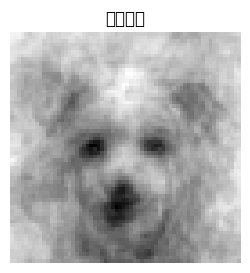

c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


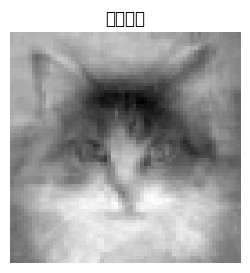

c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaey\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


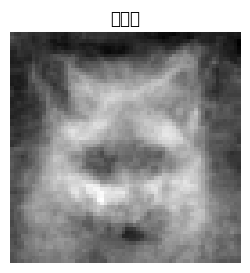


템플릿 매칭 1차 정확도
Accuracy : 0.7500

Confusion Matrix
[[7 0 0]
 [2 5 0]
 [3 0 3]]

Classification Report
              precision    recall  f1-score   support

        강아지상       0.58      1.00      0.74         7
        고양이상       1.00      0.71      0.83         7
         여우상       1.00      0.50      0.67         6

    accuracy                           0.75        20
   macro avg       0.86      0.74      0.75        20
weighted avg       0.85      0.75      0.75        20



In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

IMG_SIZE = 64

LABEL_NAME = {
    0: "강아지상",
    1: "고양이상",
    2: "토끼상",
    3: "곰상",
    4: "여우상"
}

DATASET_PATH = Path("./animal_face_dataset.csv")

if not DATASET_PATH.exists():
    raise FileNotFoundError("animal_face_dataset.csv가 없습니다. 먼저 1단계 전처리 셀을 실행하세요.")

df = pd.read_csv(DATASET_PATH)

pixel_cols = [col for col in df.columns if col.startswith("pixel_")]

X = df[pixel_cols].values / 255.0
y = df["Label"].values

existing_labels = sorted(df["Label"].unique())
existing_label_names = [LABEL_NAME[label] for label in existing_labels]

class_counts = pd.Series(y).value_counts()
can_stratify = (class_counts >= 2).all()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if can_stratify else None
)

templates = {}

for label in existing_labels:
    class_images = X_train[y_train == label]
    templates[label] = class_images.mean(axis=0)

for label in existing_labels:
    plt.figure(figsize=(3, 3))
    plt.imshow(
        templates[label].reshape(IMG_SIZE, IMG_SIZE),
        cmap="gray"
    )
    plt.title(LABEL_NAME[label])
    plt.axis("off")
    plt.show()

def predict_template_matching(image, templates):
    """
    입력 이미지와 각 동물상 평균 얼굴 템플릿 사이의
    유클리디안 거리를 계산한 뒤 가장 가까운 라벨을 반환합니다.
    """
    distances = {}

    for label, template in templates.items():
        distance = np.linalg.norm(image - template)
        distances[label] = distance

    pred_label = min(distances, key=distances.get)

    return pred_label, distances


y_pred = []

for image in X_val:
    pred_label, distances = predict_template_matching(image, templates)
    y_pred.append(pred_label)

accuracy = accuracy_score(y_val, y_pred)

print("\n템플릿 매칭 1차 정확도")
print(f"Accuracy : {accuracy:.4f}")

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_val,
        y_pred,
        labels=existing_labels
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_val,
        y_pred,
        labels=existing_labels,
        target_names=existing_label_names,
        zero_division=0
    )
)

In [3]:
df_test = pd.read_csv("./unseen_test_dataset.csv")

X_test = df_test[pixel_cols].values / 255.0
file_names = df_test["Origin_Filename"].values

results = []

for filename, x in zip(file_names, X_test):
    pred_label, distances = predict_template_matching(
    x,
    templates
)

    result = {
        "filename": filename,
        "pred_label": pred_label,
        "pred_animal": LABEL_NAME.get(pred_label, str(pred_label))
    }

    for label, dist in distances.items():
        result[f"distance_{LABEL_NAME.get(label, label)}"] = dist

    results.append(result)

df_result = pd.DataFrame(results)
df_result.to_csv("./template_matching_result.csv", index=False, encoding="utf-8-sig")

df_result.head()

,filename,pred_label,pred_animal,distance_강아지상,distance_고양이상,distance_여우상
0,Aaron_Peirsol_0001.jpg,0,강아지상,9.173513,12.768058,11.106690
1,Aaron_Peirsol_0002.jpg,0,강아지상,5.771904,9.043010,8.494653
2,Aaron_Peirsol_0003.jpg,0,강아지상,13.833216,17.660481,16.209233
3,Aaron_Peirsol_0004.jpg,0,강아지상,12.313698,12.735176,12.732209
4,Aaron_Sorkin_0001.jpg,4,여우상,15.164092,13.553358,11.560752
